# Formative 2  Hidden Markov Models

Me and my partner collected motion data from our phones to recognise
four activities: jumping, standing, walking and still. We each took
two activities and split the code work between us.

**Person 1:** Carine Umugabekazi — collected Jumping & Standing  
**Person 2:** Carine Ahishakiye — collected Walking & Still  
**Sampling rate:** 100 Hz (10 ms) on both phones via Sensor Logger  


## Task Split

| Task | Person 1 | Person 2 |
|---|:---:|:---:|
| Data collection — Jumping | ✅ | |
| Data collection — Standing | ✅ | |
| Data collection — Walking | | ✅ |
| Data collection — Still | | ✅ |
| Data loading & zip parsing | ✅ | |
| Feature extraction functions | ✅ | |
| Z-score normalization & encoding | | ✅ |
| HMM training (Baum–Welch) | ✅ | |
| Viterbi decoding implementation | | ✅ |
| Evaluation metrics & confusion matrix | ✅ | |
| Visualization (raw signals, FFT) | | ✅ |
| Visualization (HMM parameters) | ✅ | |
| Report writing | ✅ | ✅ |


In [40]:
import os
import zipfile
import warnings
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.fft import fft, fftfreq
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, ConfusionMatrixDisplay)
from hmmlearn.hmm import GaussianHMM

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams['figure.dpi']        = 120
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

print('All imports successful!')

All imports successful!


## Configuration

### Window Size
We used a 1-second window (100 samples) because a full jump cycle takes
roughly 0.5–1s. 50% overlap gives us more windows to train on.

### Sampling Rate
Both phones were set to 10 ms (100 Hz) on Sensor Logger confirmed from
Metadata.csv in each zip. No resampling needed. Person 1 used iOS,
Person 2 used Android.

### HMM Settings
- **4 states** covers the subphases of each activity without overfitting
- **Diagonal covariance** features are Zscored so off-diagonal terms add nothing
- **tol = 1e-4**  stops training when improvement is negligible, not at a fixed cap

In [41]:
BASE_DIR      = os.path.dirname(os.getcwd())
DATA_DIR      = os.path.join(BASE_DIR, 'data', 'raw')
PROCESSED_DIR = os.path.join(BASE_DIR, 'data', 'processed')
MODEL_DIR     = os.path.join(BASE_DIR, 'models')
FIG_DIR       = os.path.join(BASE_DIR, 'figures')

for d in [PROCESSED_DIR, MODEL_DIR, FIG_DIR]:
    os.makedirs(d, exist_ok=True)

ACTIVITIES  = ['jumping', 'still', 'walking', 'standing']
COLORS      = {'jumping':'tomato', 'still':'darkorange',
               'walking':'seagreen', 'standing':'steelblue'}

SAMPLE_RATE  = 100
WINDOW_SEC   = 1.0
STEP_SEC     = 0.5
WINDOW_SIZE  = int(WINDOW_SEC * SAMPLE_RATE)
STEP_SIZE    = int(STEP_SEC   * SAMPLE_RATE)

N_COMPONENTS = 4
N_ITER       = 300
TOL          = 1e-4
COV_TYPE     = 'diag'

print(f'Project root    : {BASE_DIR}')
print(f'Window          : {WINDOW_SIZE} samples = {WINDOW_SEC}s')
print(f'Step            : {STEP_SIZE} samples = {STEP_SEC}s  (50% overlap)')
print(f'Sampling rate   : {SAMPLE_RATE} Hz')
print(f'Hidden states   : {N_COMPONENTS} per HMM')
print(f'Covariance type : {COV_TYPE}')
print(f'Convergence tol : {TOL}')

Project root    : C:\Users\PC\human-activity-recognition-hmm
Window          : 100 samples = 1.0s
Step            : 50 samples = 0.5s  (50% overlap)
Sampling rate   : 100 Hz
Hidden states   : 4 per HMM
Covariance type : diag
Convergence tol : 0.0001


In [43]:
def load_sensor_from_zip(zip_path, sensor='Accelerometer'):
    """Extract one sensor CSV from a Sensor Logger zip. Returns seconds_elapsed, x, y, z."""
    with zipfile.ZipFile(zip_path, 'r') as z:
        candidates = [f for f in z.namelist()
                      if f.endswith(f'{sensor}.csv') and 'Uncalibrated' not in f]
        if not candidates:
            raise FileNotFoundError(f'{sensor}.csv not found in {zip_path}')
        with z.open(candidates[0]) as f:
            df = pd.read_csv(f)
    df.columns = df.columns.str.strip()
    return df[['seconds_elapsed', 'x', 'y', 'z']].dropna().reset_index(drop=True)


def load_activity_from_zips(activity):
    """Load all zips for one activity. Merges acc + gyro per recording on nearest timestamp."""
    act_dir   = os.path.join(DATA_DIR, activity)
    zip_files = sorted([f for f in os.listdir(act_dir) if f.endswith('.zip')])
    if not zip_files:
        raise FileNotFoundError(f'No zip files in {act_dir}')

    frames = []
    for rec_id, zf in enumerate(zip_files, start=1):
        zip_path = os.path.join(act_dir, zf)
        try:
            acc = load_sensor_from_zip(zip_path, 'Accelerometer')
            gyr = load_sensor_from_zip(zip_path, 'Gyroscope')
        except Exception as e:
            print(f'  WARNING: skipping {zf} — {e}')
            continue
        acc = acc.rename(columns={'x':'acc_x','y':'acc_y','z':'acc_z'})
        gyr = gyr.rename(columns={'x':'gyro_x','y':'gyro_y','z':'gyro_z'})

        merged = pd.merge_asof(
            acc.sort_values('seconds_elapsed'),
            gyr.sort_values('seconds_elapsed'),
            on='seconds_elapsed', direction='nearest', tolerance=0.02
        ).dropna().reset_index(drop=True)

        merged['activity']     = activity
        merged['recording_id'] = f'{activity}_{rec_id:02d}'
        frames.append(merged)

    if not frames:
        raise ValueError(f'No valid data for: {activity}')
    return pd.concat(frames, ignore_index=True)


print('Data loading functions ready.')
raw_data = {}

for act in ACTIVITIES:
    raw_data[act] = load_activity_from_zips(act)
    n_recs   = raw_data[act]['recording_id'].nunique()
    n_rows   = len(raw_data[act])
    duration = raw_data[act].groupby('recording_id')['seconds_elapsed'].max().sum()
    print(f'{act:>10} | {n_recs:>3} recordings | {n_rows:>6} rows | ~{duration:.0f}s total')

all_raw = pd.concat(raw_data.values(), ignore_index=True)
print(f'\n{"TOTAL":>10} | {all_raw["recording_id"].nunique():>3} recordings | {len(all_raw):>6} rows')

Data loading functions ready.
   jumping |  12 recordings |  13856 rows | ~141s total
     still |  12 recordings |  10413 rows | ~107s total
   walking |  13 recordings |  10436 rows | ~107s total
  standing |  13 recordings |  14595 rows | ~149s total

     TOTAL |  50 recordings |  49300 rows


In [45]:
#  DATA QUALITY VALIDATION 
print('  DATA QUALITY VALIDATION REPORT')

total_files = 0
all_pass    = True

for act in ACTIVITIES:
    act_dir   = os.path.join(DATA_DIR, act)
    zip_files = [f for f in os.listdir(act_dir) if f.endswith('.zip')]
    n_files   = len(zip_files)
    total_files += n_files

    df       = raw_data[act]
    duration = df.groupby('recording_id')['seconds_elapsed'].apply(
                   lambda x: x.max() - x.min()).sum()
    n_recs   = df['recording_id'].nunique()

    ok_dur  = duration >= 90
    if not ok_dur:
        all_pass = False

    print(f'\n  {act.upper()}')
    print(f'    Zip files found   : {n_files:>4}')
    print(f'    Recordings loaded : {n_recs:>4}')
    print(f'    Total duration    : {duration:>7.1f}s  {" PASS" if ok_dur else " need >= 90s"}')
    print(f'    Sampling rate     : {SAMPLE_RATE} Hz (10ms — confirmed via Metadata.csv)')


print(f'  Total zip files : {total_files}  {" >= 50" if total_files >= 50 else "⚠ aim for >= 50"}')
print(f'  All durations   : {" PASS" if all_pass else " CHECK ABOVE"}')
print('SAMPLE DATA PREVIEW — first 3 rows per activity')
cols = ['seconds_elapsed','acc_x','acc_y','acc_z','gyro_x','gyro_y','gyro_z','recording_id']

for act in ACTIVITIES:
    print(f'\n  {act.upper()}')
    print(raw_data[act][cols].head(3).to_string(index=False))

print(f'\nAll columns : {list(all_raw.columns)}')
print(f'Total shape : {all_raw.shape}')

  DATA QUALITY VALIDATION REPORT

  JUMPING
    Zip files found   :   12
    Recordings loaded :   12
    Total duration    :   138.5s   PASS
    Sampling rate     : 100 Hz (10ms — confirmed via Metadata.csv)

  STILL
    Zip files found   :   12
    Recordings loaded :   12
    Total duration    :   105.1s   PASS
    Sampling rate     : 100 Hz (10ms — confirmed via Metadata.csv)

  WALKING
    Zip files found   :   13
    Recordings loaded :   13
    Total duration    :   105.2s   PASS
    Sampling rate     : 100 Hz (10ms — confirmed via Metadata.csv)

  STANDING
    Zip files found   :   13
    Recordings loaded :   13
    Total duration    :   145.9s   PASS
    Sampling rate     : 100 Hz (10ms — confirmed via Metadata.csv)
  Total zip files : 50   >= 50
  All durations   :  PASS
SAMPLE DATA PREVIEW — first 3 rows per activity

  JUMPING
 seconds_elapsed    acc_x     acc_y     acc_z    gyro_x    gyro_y   gyro_z recording_id
        0.449583 0.451083 -0.349302 -0.233176 -0.796040 -0.7

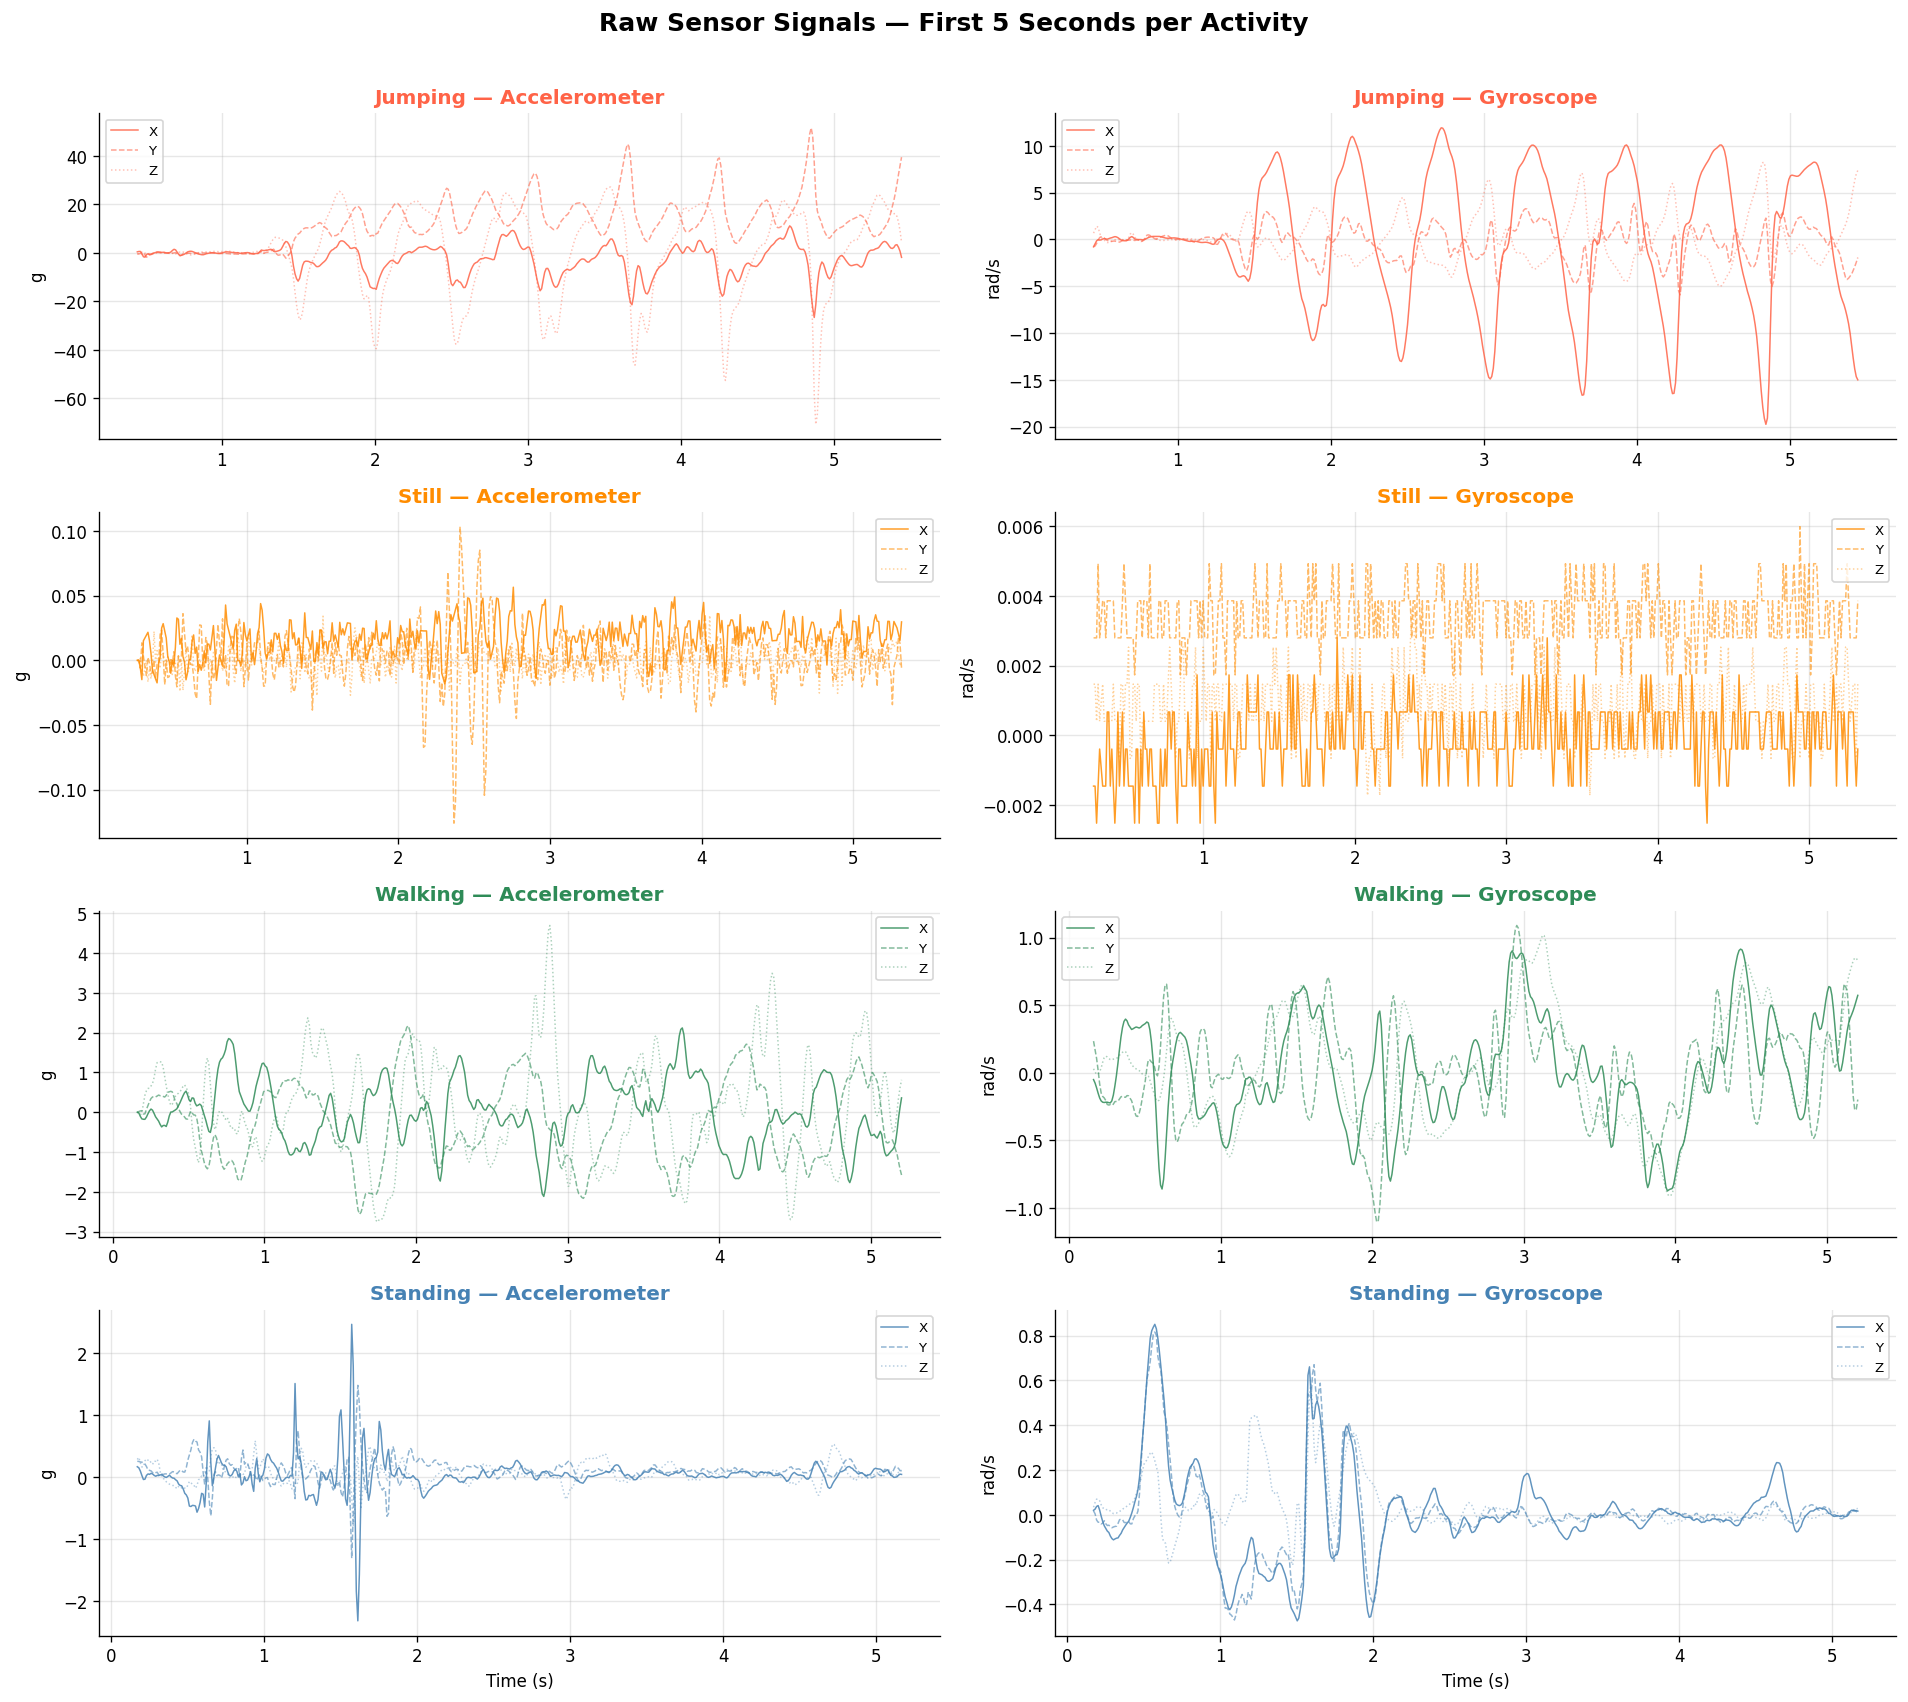

Saved: figures/raw_signals.png


In [46]:
fig, axes = plt.subplots(4, 2, figsize=(16, 14))
fig.suptitle('Raw Sensor Signals — First 5 Seconds per Activity',
             fontsize=15, fontweight='bold', y=1.01)

for i, act in enumerate(ACTIVITIES):
    df = raw_data[act].iloc[:500]
    t  = df['seconds_elapsed'].values
    c  = COLORS[act]

    axes[i,0].plot(t, df['acc_x'],  alpha=0.85, lw=0.9, label='X', color=c)
    axes[i,0].plot(t, df['acc_y'],  alpha=0.60, lw=0.9, label='Y', color=c, ls='--')
    axes[i,0].plot(t, df['acc_z'],  alpha=0.40, lw=0.9, label='Z', color=c, ls=':')
    axes[i,0].set_title(f'{act.capitalize()} — Accelerometer', fontweight='bold', color=c)
    axes[i,0].set_ylabel('g')
    axes[i,0].legend(fontsize=8)
    axes[i,0].grid(alpha=0.3)

    axes[i,1].plot(t, df['gyro_x'], alpha=0.85, lw=0.9, label='X', color=c)
    axes[i,1].plot(t, df['gyro_y'], alpha=0.60, lw=0.9, label='Y', color=c, ls='--')
    axes[i,1].plot(t, df['gyro_z'], alpha=0.40, lw=0.9, label='Z', color=c, ls=':')
    axes[i,1].set_title(f'{act.capitalize()} — Gyroscope', fontweight='bold', color=c)
    axes[i,1].set_ylabel('rad/s')
    axes[i,1].legend(fontsize=8)
    axes[i,1].grid(alpha=0.3)

for ax in axes[-1]:
    ax.set_xlabel('Time (s)')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'raw_signals.png'), bbox_inches='tight')
plt.show()
print('Saved: figures/raw_signals.png')

In [47]:
def extract_features(window):
    """Extract 26 features from one 1-second window (WINDOW_SIZE samples)."""
    feats = {}
    sensor_cols = ['acc_x','acc_y','acc_z','gyro_x','gyro_y','gyro_z']

    for col in sensor_cols:
        sig = window[col].values
        feats[f'{col}_mean'] = np.mean(sig)
        feats[f'{col}_var']  = np.var(sig)
        feats[f'{col}_std']  = np.std(sig)
        feats[f'{col}_rms']  = np.sqrt(np.mean(sig**2))

    feats['acc_sma']  = (np.abs(window['acc_x']) + np.abs(window['acc_y'])
                        + np.abs(window['acc_z'])).mean()
    feats['gyro_sma'] = (np.abs(window['gyro_x']) + np.abs(window['gyro_y'])
                        + np.abs(window['gyro_z'])).mean()

  
    feats['acc_corr_xy'] = np.corrcoef(window['acc_x'], window['acc_y'])[0,1]
    feats['acc_corr_xz'] = np.corrcoef(window['acc_x'], window['acc_z'])[0,1]


    for col in ['acc_x','acc_y','acc_z']:
        sig      = window[col].values
        N        = len(sig)
        freqs    = fftfreq(N, d=1.0/SAMPLE_RATE)
        mag      = np.abs(fft(sig))[:N//2]
        pos_f    = freqs[:N//2]
        feats[f'{col}_dom_freq']     = pos_f[np.argmax(mag)]
        feats[f'{col}_spec_energy']  = np.sum(mag**2) / N
        mag_norm = mag / (np.sum(mag) + 1e-10)
        feats[f'{col}_spec_entropy'] = -np.sum(mag_norm * np.log(mag_norm + 1e-10))

    return feats


def window_and_extract(df):
    """Slide a 1-second window with 50% overlap over one recording."""
    records = []
    n = len(df)
    for start in range(0, n - WINDOW_SIZE + 1, STEP_SIZE):
        w     = df.iloc[start:start + WINDOW_SIZE]
        feats = extract_features(w)
        feats['activity']     = w['activity'].iloc[0]
        feats['recording_id'] = w['recording_id'].iloc[0]
        records.append(feats)
    return records


print('Feature extraction functions ready.')

Feature extraction functions ready.


   jumping — done
     still — done
   walking — done
  standing — done

Feature matrix : 915 windows  x  37 features

Windows per activity:
activity
standing    272
jumping     260
still       192
walking     191


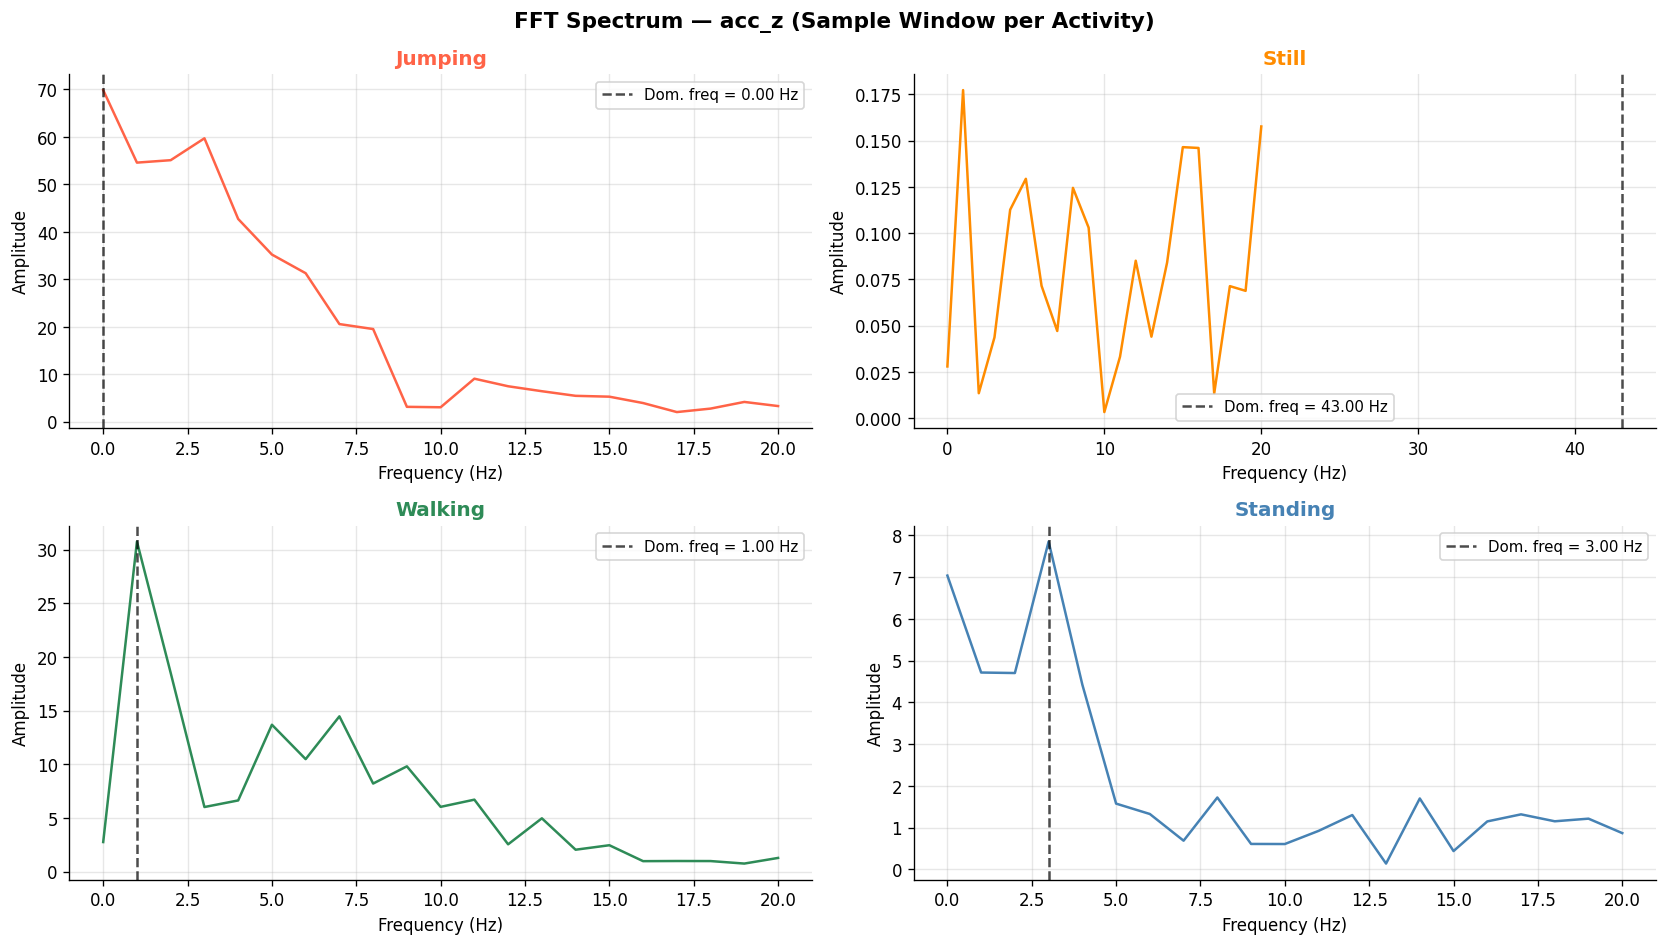

Saved: figures/fft_per_activity.png


In [48]:
all_records = []

for act in ACTIVITIES:
    for rec_id, rec_df in raw_data[act].groupby('recording_id'):
        all_records.extend(window_and_extract(rec_df.reset_index(drop=True)))
    print(f'{act:>10} — done')

features_df  = pd.DataFrame(all_records)
meta_cols    = ['activity', 'recording_id']
feature_cols = [c for c in features_df.columns if c not in meta_cols]
features_df[feature_cols] = features_df[feature_cols].fillna(0)

print(f'\nFeature matrix : {features_df.shape[0]} windows  x  {len(feature_cols)} features')
print('\nWindows per activity:')
print(features_df['activity'].value_counts().to_string())
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('FFT Spectrum — acc_z (Sample Window per Activity)',
             fontsize=13, fontweight='bold')

for ax, act in zip(axes.flatten(), ACTIVITIES):
    rec_df   = raw_data[act].groupby('recording_id').get_group(
                   raw_data[act]['recording_id'].unique()[0]).reset_index(drop=True)
    signal   = rec_df['acc_z'].values[:WINDOW_SIZE]
    N        = len(signal)
    freqs    = fftfreq(N, d=1.0/SAMPLE_RATE)
    mag      = np.abs(fft(signal))[:N//2]
    pos_f    = freqs[:N//2]
    mask_f   = pos_f <= 20
    dom_freq = pos_f[np.argmax(mag)]

    ax.plot(pos_f[mask_f], mag[mask_f], color=COLORS[act], lw=1.5)
    ax.axvline(dom_freq, color='black', ls='--', alpha=0.7,
               label=f'Dom. freq = {dom_freq:.2f} Hz')
    ax.set_title(act.capitalize(), fontweight='bold', color=COLORS[act])
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Amplitude')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fft_per_activity.png'), bbox_inches='tight')
plt.show()
print('Saved: figures/fft_per_activity.png')

In [49]:
X_raw = features_df[feature_cols].values
y     = features_df['activity'].values

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

le          = LabelEncoder()
y_enc       = le.fit_transform(y)
class_names = le.classes_

print('Z-score normalization applied.')
print(f'Mean after scaling : {X_scaled.mean():.6f}  (target ~0)')
print(f'Std  after scaling : {X_scaled.std():.6f}   (target ~1)')
print()
print('Label encoding:')
for cls, enc in zip(class_names, le.transform(class_names)):
    print(f'  {cls:>10}  ->  {enc}')

with open(os.path.join(MODEL_DIR, 'scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)
with open(os.path.join(MODEL_DIR, 'label_encoder.pkl'), 'wb') as f:
    pickle.dump(le, f)

print('\nSaved: models/scaler.pkl')
print('Saved: models/label_encoder.pkl')

Z-score normalization applied.
Mean after scaling : -0.000000  (target ~0)
Std  after scaling : 1.000000   (target ~1)

Label encoding:
     jumping  ->  0
    standing  ->  1
       still  ->  2
     walking  ->  3

Saved: models/scaler.pkl
Saved: models/label_encoder.pkl


In [50]:
features_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)
features_scaled_df['activity']     = features_df['activity'].values
features_scaled_df['recording_id'] = features_df['recording_id'].values
features_scaled_df['label_enc']    = y_enc

out_path = os.path.join(PROCESSED_DIR, 'features_normalized.csv')
features_scaled_df.to_csv(out_path, index=False)
print(f'Saved: {out_path}')
print(f'Shape: {features_scaled_df.shape}')

Saved: C:\Users\PC\human-activity-recognition-hmm\data\processed\features_normalized.csv
Shape: (915, 40)


## Train / Test Split
The **last 2 recordings per activity** are held out as a completely unseen test set.  
This satisfies the rubric requirement of testing on at least 2 unseen files per activity, 
and ensures no test data was seen during Baum–Welch training.

In [51]:
#  TRAIN / TEST SPLIT 
train_idx, test_idx = [], []

print('TRAIN / TEST SPLIT (2 unseen recordings held out per activity)')

for act in ACTIVITIES:
    act_recs   = sorted(
        features_scaled_df[features_scaled_df['activity'] == act
        ]['recording_id'].unique()
    )
    test_recs  = set(act_recs[-2:])   # last 2 = unseen test
    train_recs = set(act_recs[:-2])

    print(f'\n  {act.upper()}')
    print(f'    Train : {sorted(train_recs)}')
    print(f'    Test  : {sorted(test_recs)}  <- unseen')

    for idx in features_scaled_df[features_scaled_df['activity'] == act].index:
        rec = features_scaled_df.loc[idx, 'recording_id']
        if rec in test_recs:
            test_idx.append(idx)
        else:
            train_idx.append(idx)

X_train = X_scaled[train_idx]
y_train = features_scaled_df.loc[train_idx, 'activity'].values
X_test  = X_scaled[test_idx]
y_test  = features_scaled_df.loc[test_idx,  'activity'].values

print(f'  Training windows : {len(y_train)}')
print(f'  Test windows     : {len(y_test)}  (2 unseen recordings per activity)')
print()
print('Training windows per activity:')
print(pd.Series(y_train).value_counts().to_string())
print()
print('Test windows per activity:')
print(pd.Series(y_test).value_counts().to_string())

TRAIN / TEST SPLIT (2 unseen recordings held out per activity)

  JUMPING
    Train : ['jumping_01', 'jumping_02', 'jumping_03', 'jumping_04', 'jumping_05', 'jumping_06', 'jumping_07', 'jumping_08', 'jumping_09', 'jumping_10']
    Test  : ['jumping_11', 'jumping_12']  <- unseen

  STILL
    Train : ['still_01', 'still_02', 'still_03', 'still_04', 'still_05', 'still_06', 'still_07', 'still_08', 'still_09', 'still_10']
    Test  : ['still_11', 'still_12']  <- unseen

  WALKING
    Train : ['walking_01', 'walking_02', 'walking_03', 'walking_04', 'walking_05', 'walking_06', 'walking_07', 'walking_08', 'walking_09', 'walking_10', 'walking_11']
    Test  : ['walking_12', 'walking_13']  <- unseen

  STANDING
    Train : ['standing_01', 'standing_02', 'standing_03', 'standing_04', 'standing_05', 'standing_06', 'standing_07', 'standing_08', 'standing_09', 'standing_10', 'standing_11']
    Test  : ['standing_12', 'standing_13']  <- unseen
  Training windows : 774
  Test windows     : 141  (2 uns

## HMM Training  Baum–Welch Algorithm
One `GaussianHMM` is trained per activity using the **Baum–Welch (EM) algorithm**.

**Convergence criterion:** training stops when the per-iteration log-likelihood 
improvement falls below `tol = 1e-4`. This is a principled convergence check 
not an arbitrary iteration cap  ensuring each model reaches a stable optimum 
without over-fitting.

In [53]:
models   = {}
train_ll = {}

print(f'  {"Activity":>10}  {"Windows":>7}  {"Iterations":>10}  {"Train LL":>12}')
train_df = features_scaled_df.loc[train_idx]

for act in ACTIVITIES:
    act_df  = train_df[train_df['activity'] == act]
    seqs    = []
    lengths = []

    for rec in act_df['recording_id'].unique():
        idx = act_df[act_df['recording_id'] == rec].index
        seq = X_scaled[idx]
        if len(seq) > 0:
            seqs.append(seq)
            lengths.append(len(seq))

    X_act = np.vstack(seqs)

    model = GaussianHMM(
        n_components=N_COMPONENTS,
        covariance_type=COV_TYPE,
        n_iter=N_ITER,
        tol=TOL,
        verbose=False,
        random_state=42,
        init_params='mc'  
    )
    model.startprob_ = np.full(N_COMPONENTS, 1.0 / N_COMPONENTS)
    model.transmat_  = np.full((N_COMPONENTS, N_COMPONENTS), 1.0 / N_COMPONENTS)
    model.fit(X_act, lengths)

    for i in range(N_COMPONENTS):
        rs = model.transmat_[i].sum()
        if rs == 0:
            model.transmat_[i] = np.full(N_COMPONENTS, 1.0 / N_COMPONENTS)
        else:
            model.transmat_[i] /= rs

    models[act]   = model
    train_ll[act] = model.score(X_act, lengths)
    print(f'  {act:>10}  {X_act.shape[0]:>7}  '
          f'{model.monitor_.iter:>10}  {train_ll[act]:>12.2f}')

print()
print('Baum-Welch training complete.')

with open(os.path.join(MODEL_DIR, 'hmm_models.pkl'), 'wb') as f:
    pickle.dump(models, f)
print('Saved: models/hmm_models.pkl')

    Activity  Windows  Iterations      Train LL
     jumping      218          11      -6196.61
       still      167           6      18151.66
     walking      159          16       3882.05


Model is not converging.  Current: 18006.56831674764 is not greater than 18007.662154037724. Delta is -1.093837290081865


    standing      230          11      18005.07

Baum-Welch training complete.
Saved: models/hmm_models.pkl


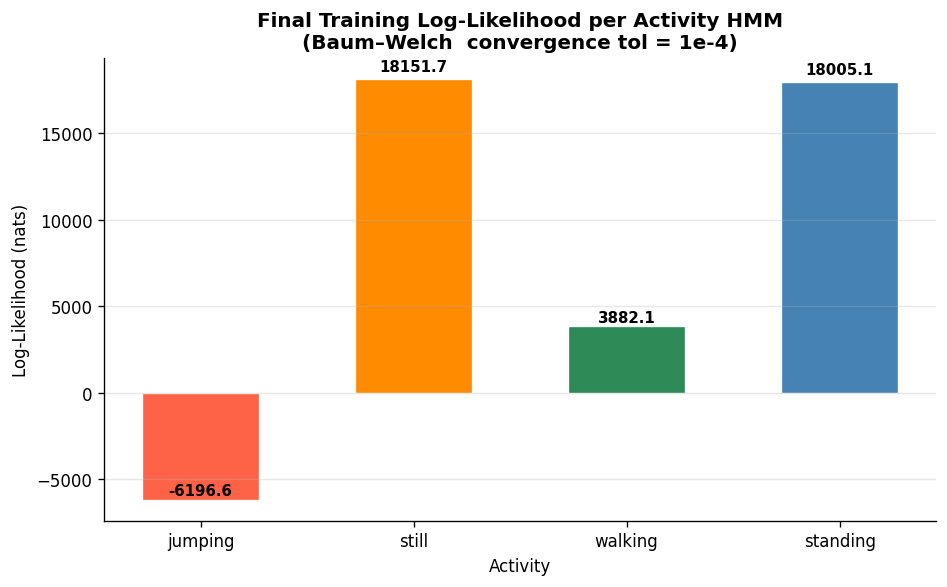

Saved: figures/baum_welch_convergence.png


In [54]:
fig, ax = plt.subplots(figsize=(8, 5))
acts = list(train_ll.keys())
lls  = [train_ll[a] for a in acts]
bars = ax.bar(acts, lls, color=[COLORS[a] for a in acts],
              edgecolor='white', lw=0.8, width=0.55)
for bar, val in zip(bars, lls):
    ax.text(bar.get_x() + bar.get_width()/2, val + abs(val)*0.015,
            f'{val:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title('Final Training Log-Likelihood per Activity HMM\n'
             '(Baum–Welch  convergence tol = 1e-4)', fontweight='bold')
ax.set_ylabel('Log-Likelihood (nats)')
ax.set_xlabel('Activity')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'baum_welch_convergence.png'), bbox_inches='tight')
plt.show()
print('Saved: figures/baum_welch_convergence.png')

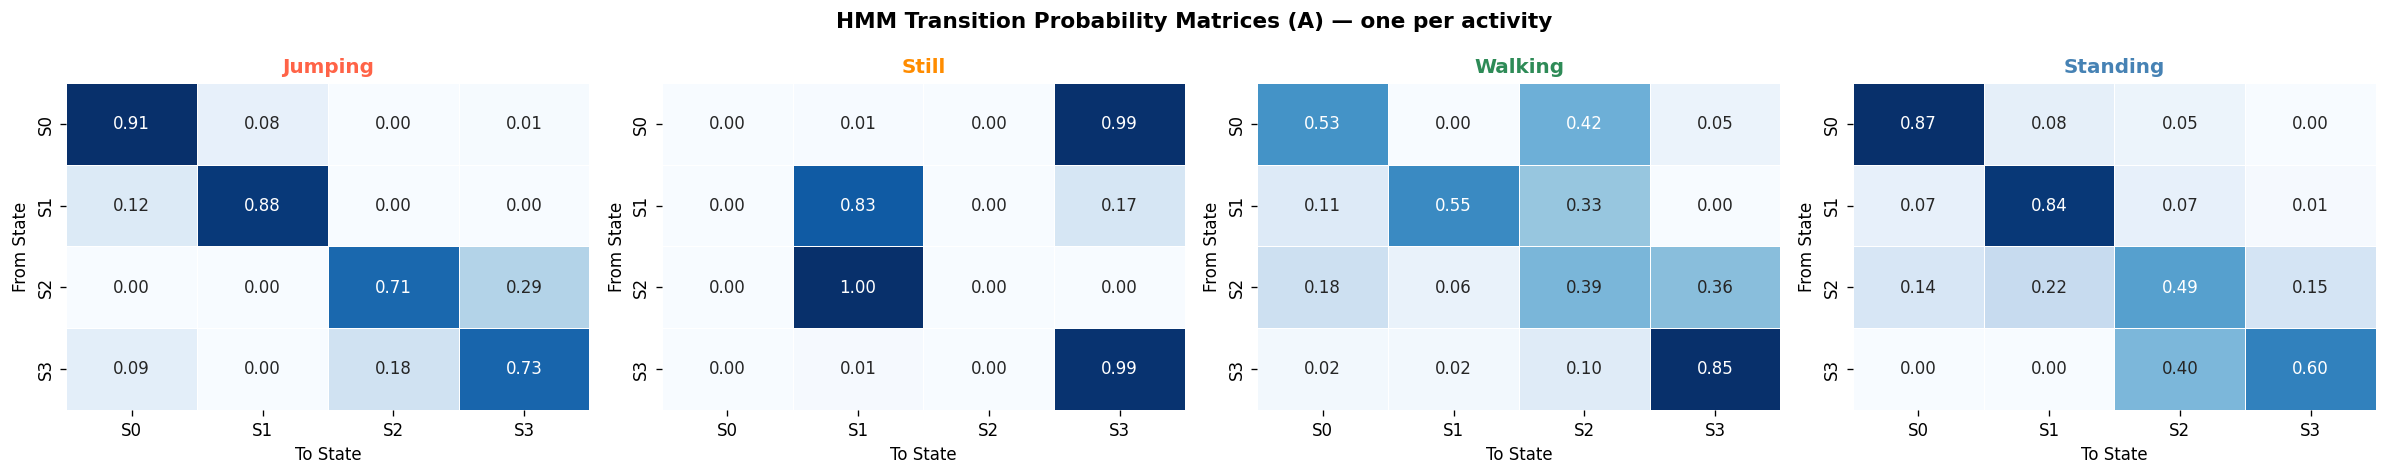

Saved: figures/transition_matrices.png


In [55]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle('HMM Transition Probability Matrices (A) — one per activity',
             fontsize=13, fontweight='bold')
for ax, act in zip(axes, ACTIVITIES):
    trans = models[act].transmat_
    n     = trans.shape[0]
    sns.heatmap(trans, annot=True, fmt='.2f', cmap='Blues',
                ax=ax, cbar=False, linewidths=0.5,
                xticklabels=[f'S{i}' for i in range(n)],
                yticklabels=[f'S{i}' for i in range(n)])
    ax.set_title(act.capitalize(), fontweight='bold', color=COLORS[act])
    ax.set_xlabel('To State')
    ax.set_ylabel('From State')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'transition_matrices.png'), bbox_inches='tight')
plt.show()
print('Saved: figures/transition_matrices.png')

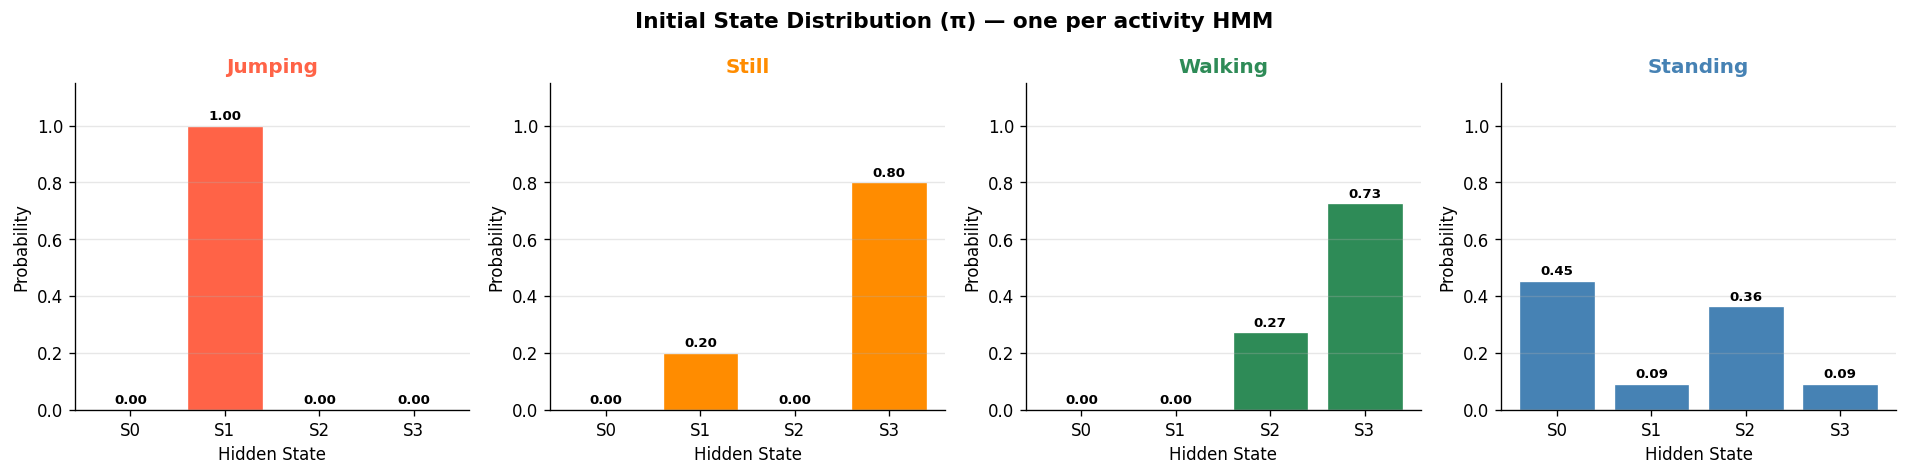

Saved: figures/initial_state_distribution.png


In [56]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Initial State Distribution (π) — one per activity HMM',
             fontsize=13, fontweight='bold')
for ax, act in zip(axes, ACTIVITIES):
    pi   = models[act].startprob_
    bars = ax.bar([f'S{i}' for i in range(len(pi))], pi,
                  color=COLORS[act], edgecolor='white', lw=0.8)
    for bar, val in zip(bars, pi):
        ax.text(bar.get_x()+bar.get_width()/2, val+0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_title(act.capitalize(), fontweight='bold', color=COLORS[act])
    ax.set_xlabel('Hidden State')
    ax.set_ylabel('Probability')
    ax.set_ylim(0, 1.15)
    ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'initial_state_distribution.png'), bbox_inches='tight')
plt.show()
print('Saved: figures/initial_state_distribution.png')

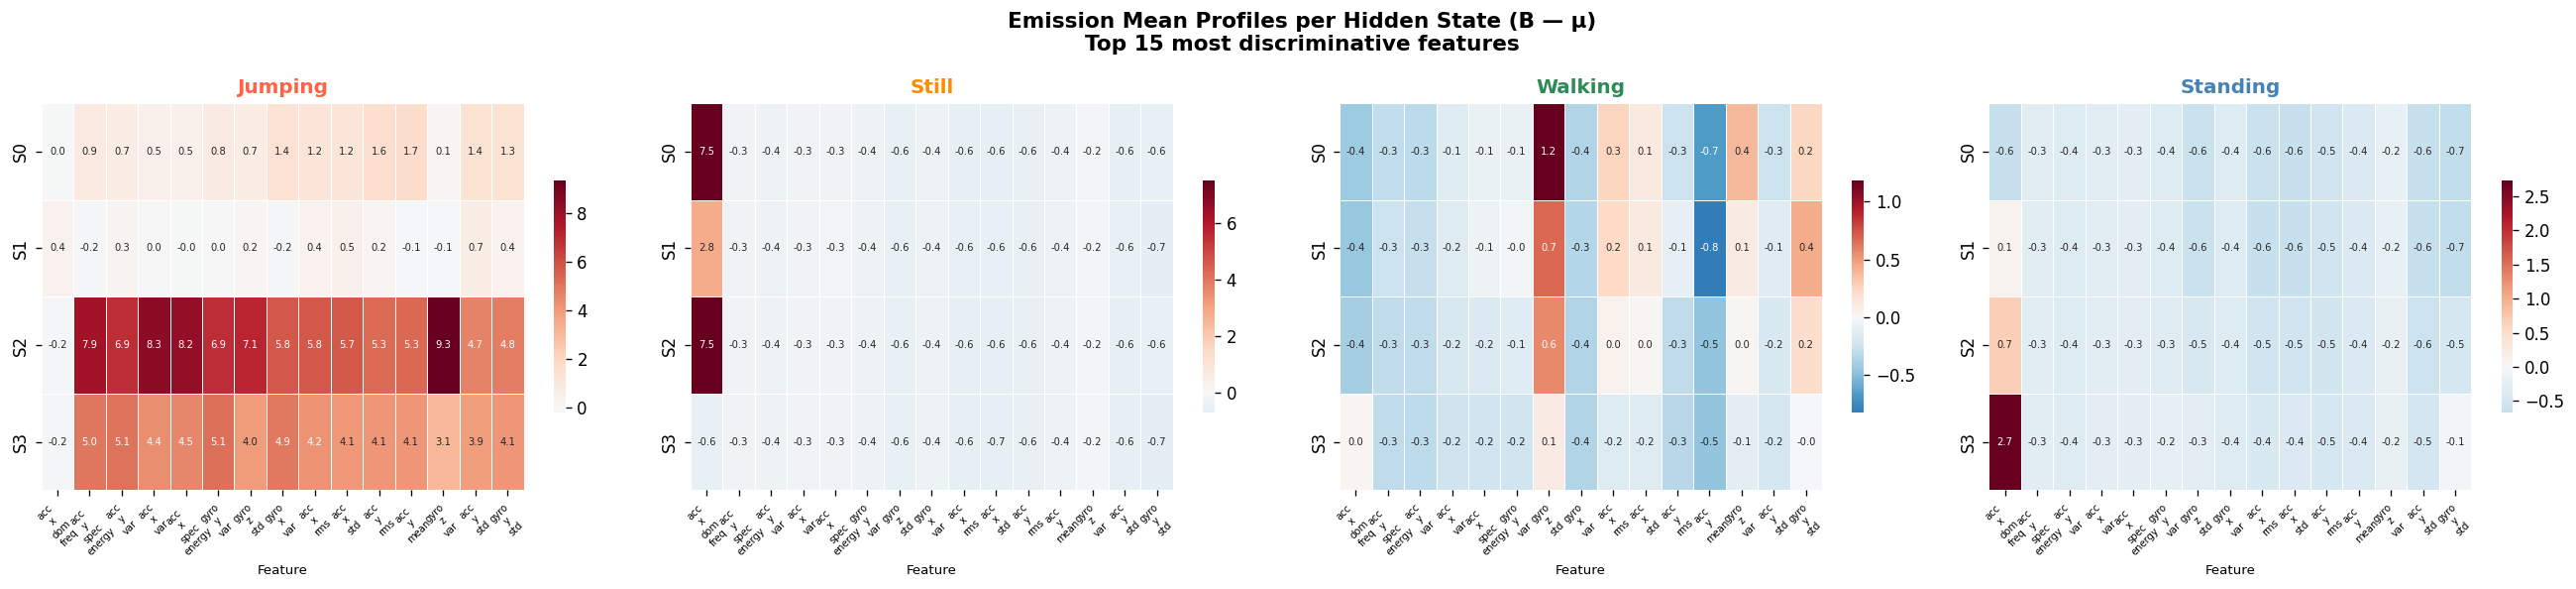

Saved: figures/emission_means_heatmap.png


In [57]:
all_means = np.stack([models[act].means_.mean(axis=0) for act in ACTIVITIES])
top_idx   = np.argsort(all_means.var(axis=0))[::-1][:15]
top_feats = [feature_cols[i] for i in top_idx]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('Emission Mean Profiles per Hidden State (B — μ)\n'
             'Top 15 most discriminative features', fontsize=13, fontweight='bold')
for ax, act in zip(axes, ACTIVITIES):
    sns.heatmap(models[act].means_[:, top_idx],
                ax=ax, cmap='RdBu_r', center=0,
                annot=True, fmt='.1f', annot_kws={'fontsize':6},
                linewidths=0.3,
                xticklabels=[f.replace('_','\n') for f in top_feats],
                yticklabels=[f'S{i}' for i in range(N_COMPONENTS)],
                cbar=True, cbar_kws={'shrink':0.6})
    ax.set_title(act.capitalize(), fontweight='bold', color=COLORS[act])
    ax.set_xlabel('Feature', fontsize=8)
    ax.tick_params(axis='x', labelsize=6, rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'emission_means_heatmap.png'), bbox_inches='tight')
plt.show()
print('Saved: figures/emission_means_heatmap.png')

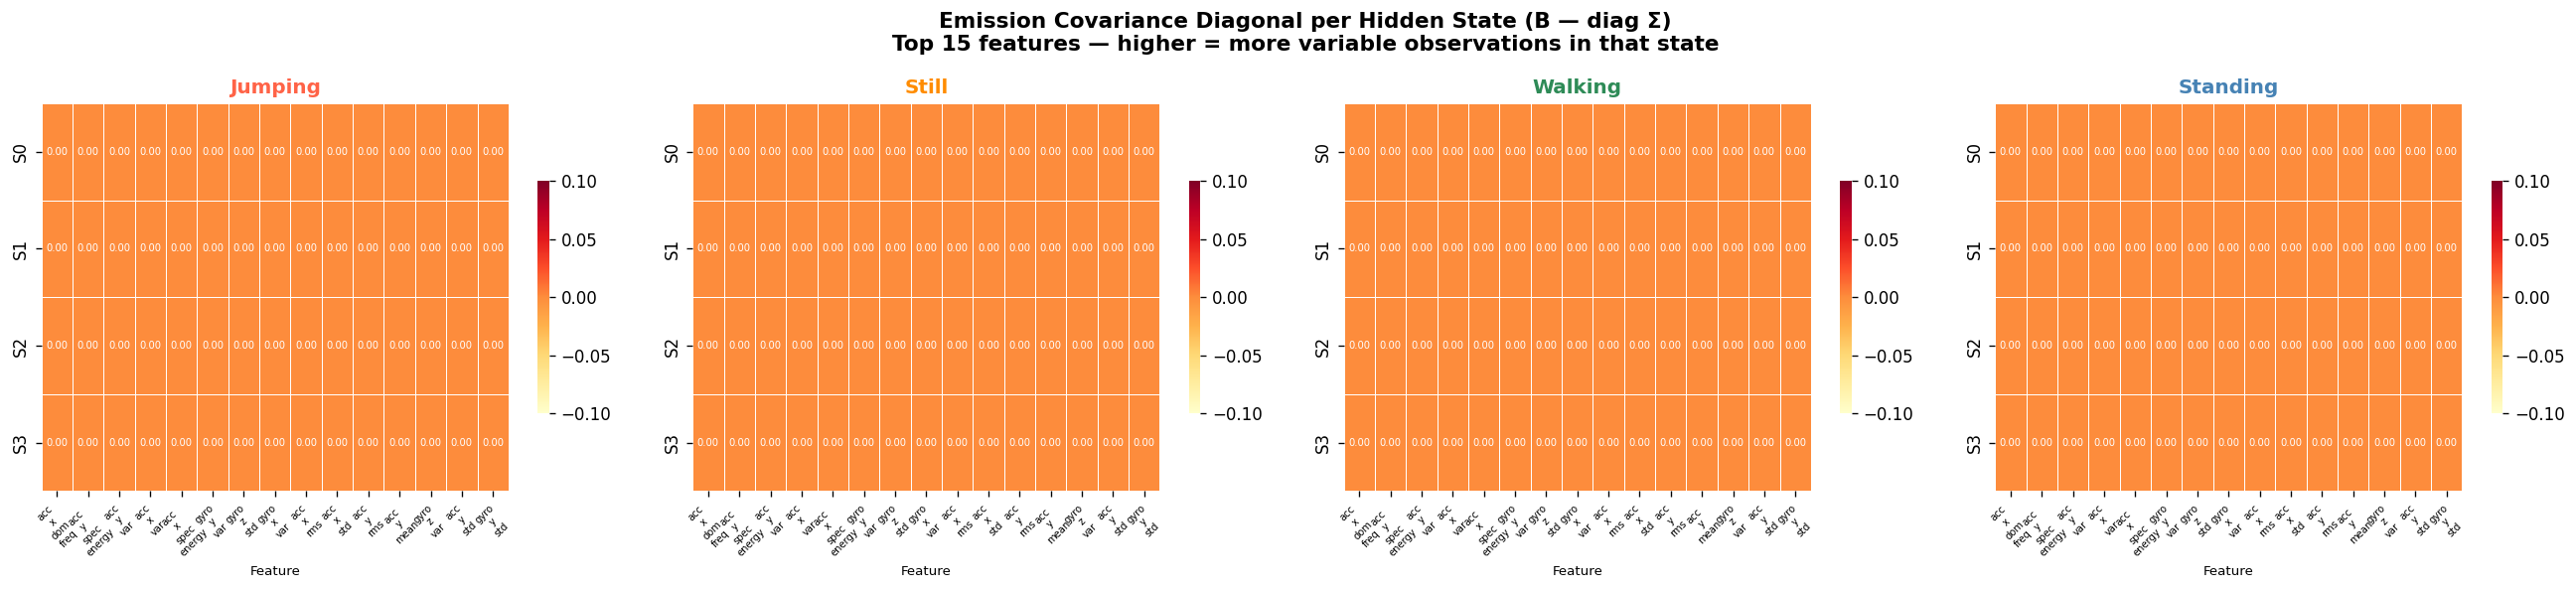

Saved: figures/emission_covariance_heatmap.png


In [58]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('Emission Covariance Diagonal per Hidden State (B — diag Σ)\n'
             'Top 15 features — higher = more variable observations in that state',
             fontsize=13, fontweight='bold')
for ax, act in zip(axes, ACTIVITIES):
    covars = models[act].covars_
    if covars.ndim == 3:
        covars = covars[:, 0, :]
    sns.heatmap(covars[:, top_idx],
                ax=ax, cmap='YlOrRd',
                annot=True, fmt='.2f', annot_kws={'fontsize':6},
                linewidths=0.3,
                xticklabels=[f.replace('_','\n') for f in top_feats],
                yticklabels=[f'S{i}' for i in range(N_COMPONENTS)],
                cbar=True, cbar_kws={'shrink':0.6})
    ax.set_title(act.capitalize(), fontweight='bold', color=COLORS[act])
    ax.set_xlabel('Feature', fontsize=8)
    ax.tick_params(axis='x', labelsize=6, rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'emission_covariance_heatmap.png'), bbox_inches='tight')
plt.show()
print('Saved: figures/emission_covariance_heatmap.png')

## Viterbi Decoding

The **Viterbi algorithm** finds the most likely hidden state sequence given an 
observation sequence and trained HMM parameters, using dynamic programming:

$$Z^* = \arg\max_{Z} \ P(Z \mid X,\, \lambda)$$

where $Z$ is the hidden state path, $X$ the observation sequence, and 
$\lambda = (A, B, \pi)$ the HMM parameters.

`model.decode(algorithm='viterbi')` returns:
1. The **log-probability** of the best path
2. The **state sequence** — which hidden state was active at each time step

This reveals the *internal sub-phase structure* of each activity (e.g. the 
crouch → launch → airborne → landing cycle within Jumping), which is distinct 
from cross-model likelihood classification.

In [59]:
# TRUE VITERBI DECODING 

print('VITERBI HIDDEN STATE DECODING')
viterbi_results = {}

for act in ACTIVITIES:

    test_recs = sorted(
        features_scaled_df[features_scaled_df['activity'] == act
        ]['recording_id'].unique()
    )[-2:]  

    test_rec = test_recs[0]   
    idx_seq  = features_scaled_df[
        features_scaled_df['recording_id'] == test_rec
    ].index
    X_seq = X_scaled[idx_seq]

    if len(X_seq) < 2:
        print(f'  {act}: too few windows, skipping')
        continue

    # THE VITERBI CALL
    logprob, state_seq = models[act].decode(X_seq, algorithm='viterbi')

    viterbi_results[act] = {
        'logprob'  : logprob,
        'state_seq': state_seq,
        'n_windows': len(state_seq),
        'rec_id'   : test_rec
    }

    unique, counts = np.unique(state_seq, return_counts=True)
    occ = {f'S{s}': f'{c/len(state_seq)*100:.1f}%' for s, c in zip(unique, counts)}

    print(f'\n  {act.upper()} — {test_rec}')
    print(f'    Windows decoded  : {len(state_seq)}')
    print(f'    Viterbi log-prob : {logprob:.2f} nats')
    print(f'    State occupancy  : {occ}')

print('\nViterbi decoding complete.')

VITERBI HIDDEN STATE DECODING

  JUMPING — jumping_11
    Windows decoded  : 22
    Viterbi log-prob : -687.88 nats
    State occupancy  : {'S0': '59.1%', 'S1': '40.9%'}

  STILL — still_11
    Windows decoded  : 11
    Viterbi log-prob : 1171.58 nats
    State occupancy  : {'S1': '9.1%', 'S3': '90.9%'}

  WALKING — walking_12
    Windows decoded  : 21
    Viterbi log-prob : 532.96 nats
    State occupancy  : {'S0': '4.8%', 'S1': '4.8%', 'S2': '33.3%', 'S3': '57.1%'}

  STANDING — standing_12
    Windows decoded  : 22
    Viterbi log-prob : 1560.69 nats
    State occupancy  : {'S1': '68.2%', 'S2': '22.7%', 'S3': '9.1%'}

Viterbi decoding complete.


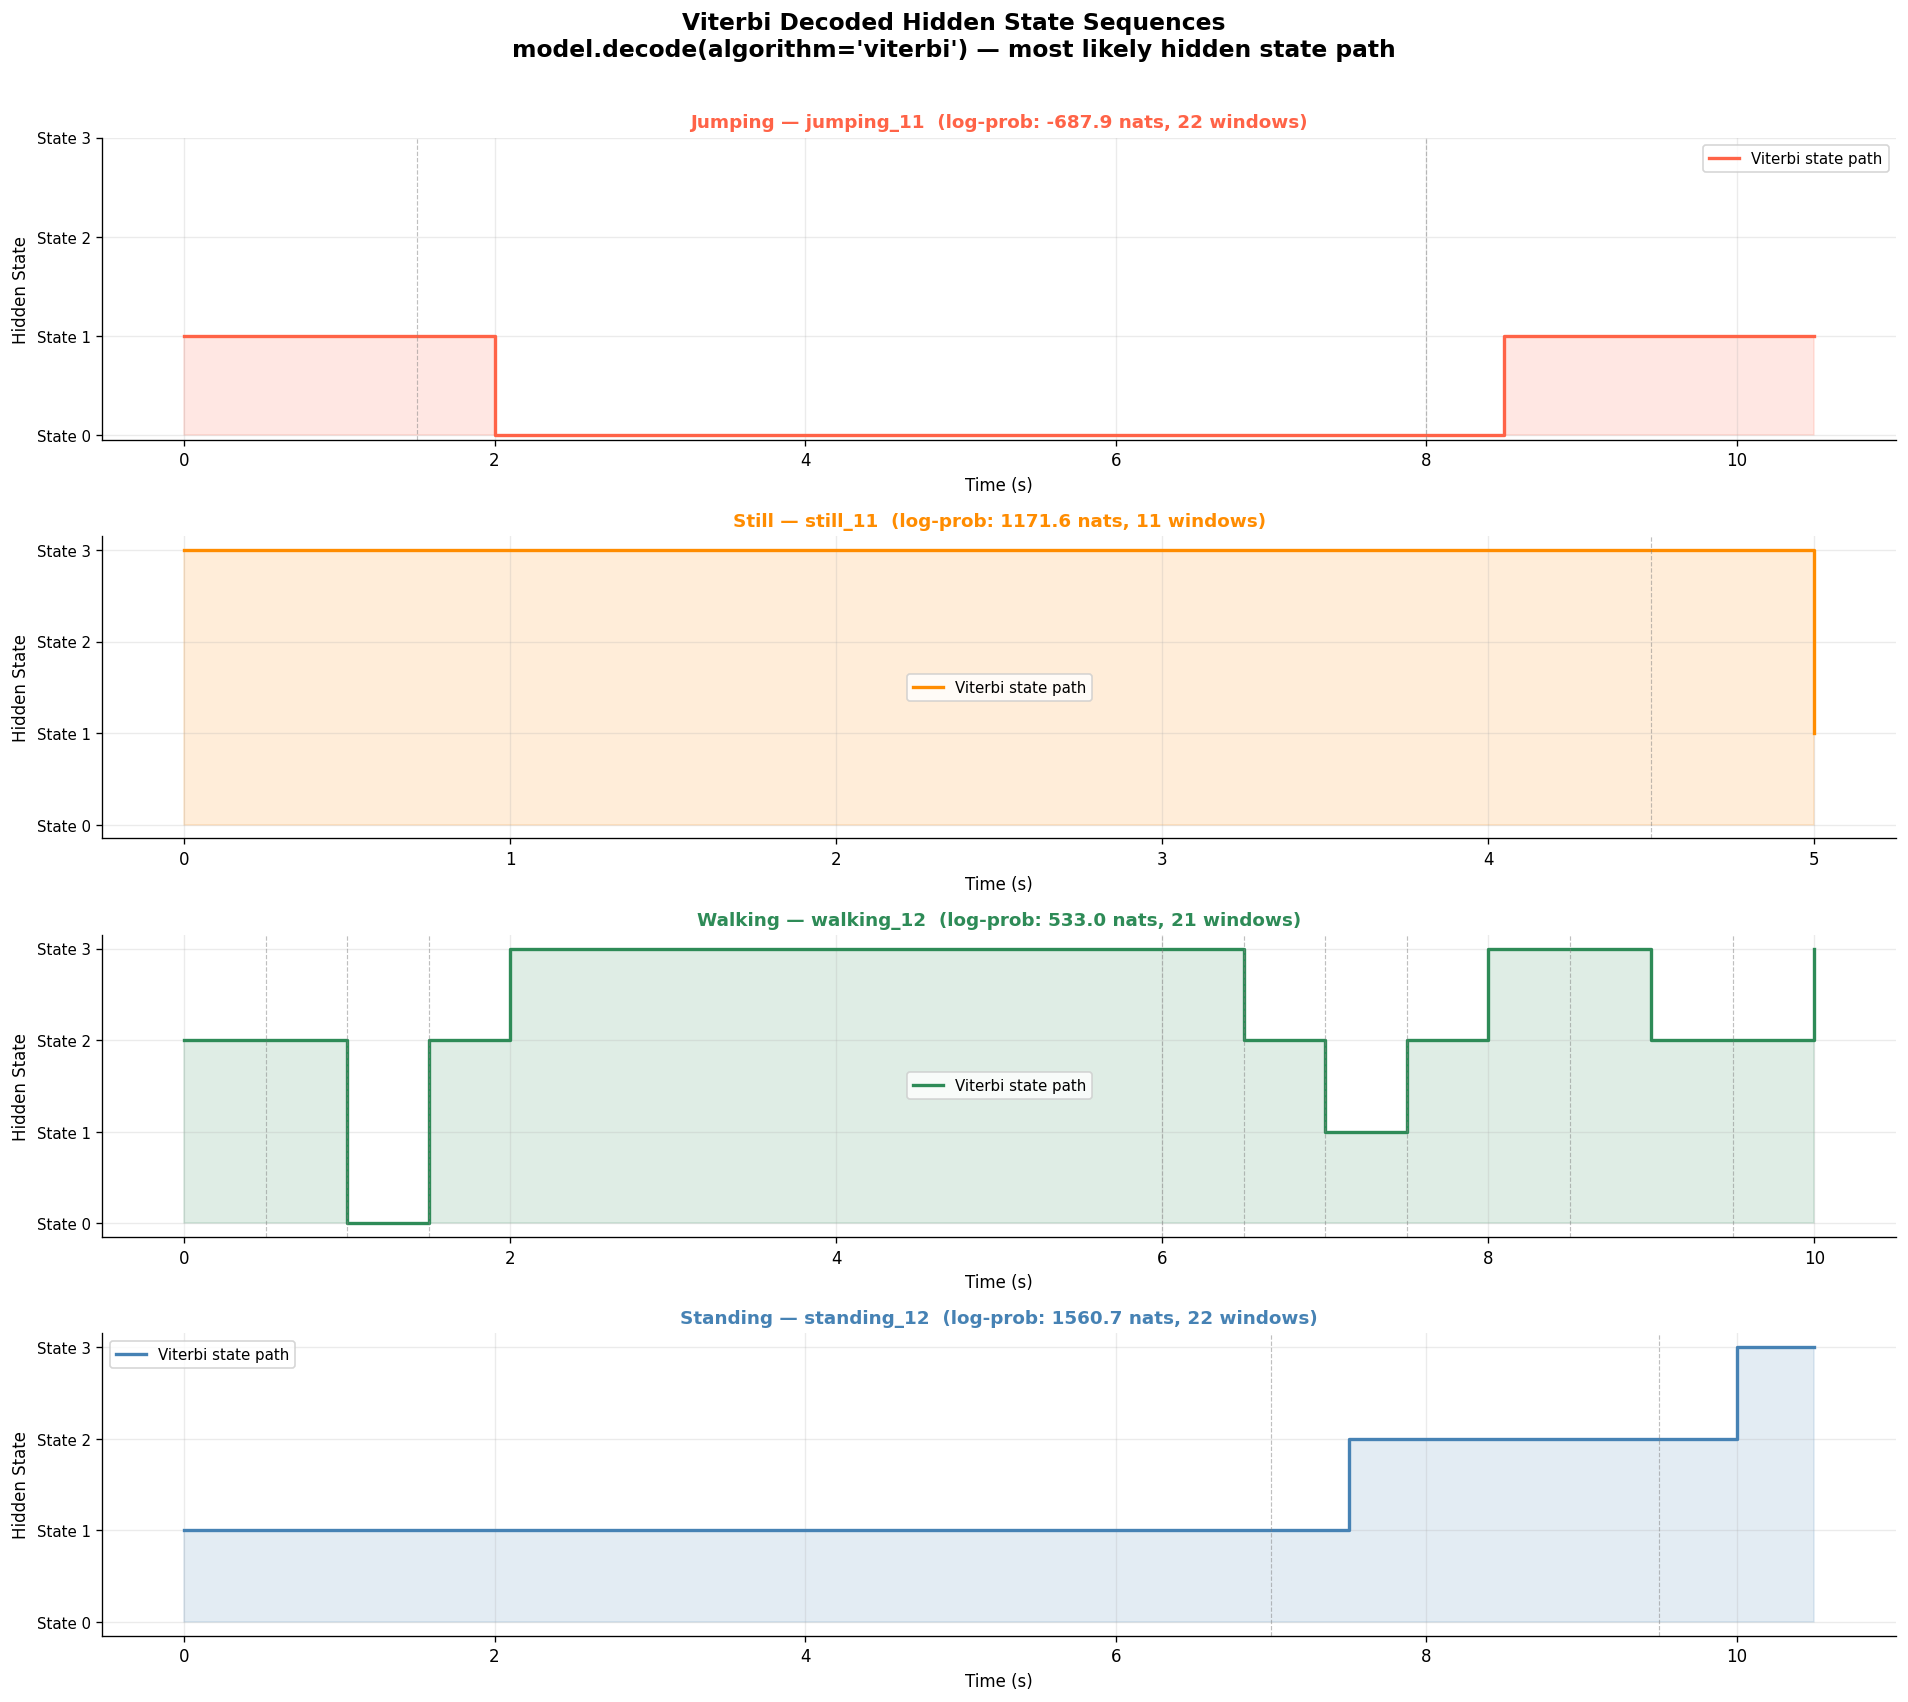

Saved: figures/viterbi_state_paths.png


In [60]:
# VITERBI STATE PATH PLOT 
fig, axes = plt.subplots(len(viterbi_results), 1,
                         figsize=(16, 3.5 * len(viterbi_results)),
                         sharex=False)
if len(viterbi_results) == 1:
    axes = [axes]

fig.suptitle('Viterbi Decoded Hidden State Sequences\n'
             'model.decode(algorithm=\'viterbi\') — most likely hidden state path',
             fontsize=14, fontweight='bold', y=1.01)

for ax, (act, res) in zip(axes, viterbi_results.items()):
    state_seq = res['state_seq']
    t         = np.arange(len(state_seq)) * STEP_SEC

    ax.step(t, state_seq, where='post',
            color=COLORS[act], lw=2.0, label='Viterbi state path')
    ax.fill_between(t, state_seq, step='post', alpha=0.15, color=COLORS[act])

    # Mark state transitions
    for tr in np.where(np.diff(state_seq) != 0)[0]:
        ax.axvline(t[tr], color='grey', lw=0.7, alpha=0.5, ls='--')

    ax.set_yticks(range(N_COMPONENTS))
    ax.set_yticklabels([f'State {i}' for i in range(N_COMPONENTS)], fontsize=9)
    ax.set_title(
        f'{act.capitalize()} — {res["rec_id"]}  '
        f'(log-prob: {res["logprob"]:.1f} nats, {res["n_windows"]} windows)',
        fontweight='bold', color=COLORS[act], fontsize=11
    )
    ax.set_xlabel('Time (s)', fontsize=10)
    ax.set_ylabel('Hidden State', fontsize=10)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'viterbi_state_paths.png'), bbox_inches='tight')
plt.show()
print('Saved: figures/viterbi_state_paths.png')

## Activity Classification on Test Set
Each test window is classified by computing its log-likelihood under every 
trained HMM and selecting the model with the highest score 
maximum-likelihood decoding across models.

Classification complete: 141 test windows predicted


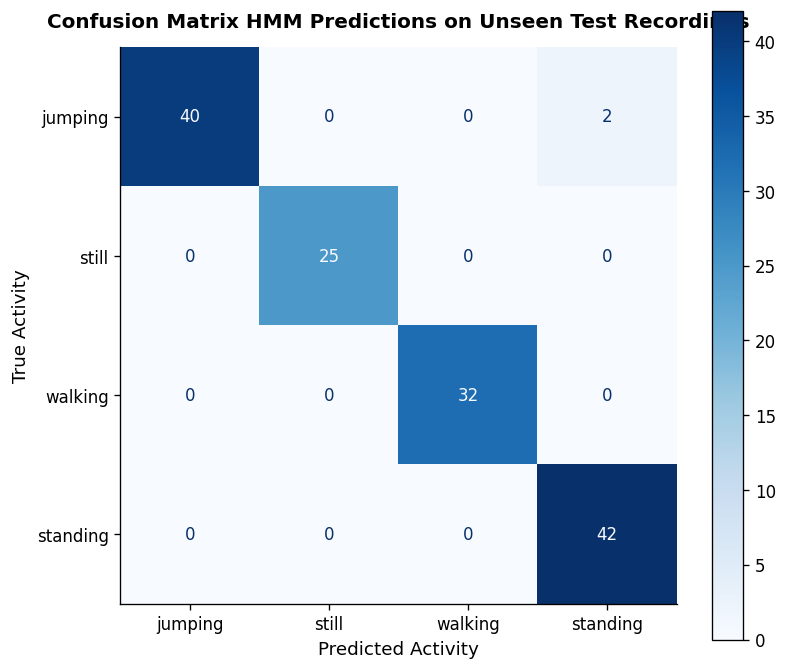

Saved: figures/confusion_matrix.png


In [62]:
y_pred = []

for x in X_test:
    scores = {act: models[act].score(x.reshape(1, -1)) for act in ACTIVITIES}
    pred   = max(scores, key=scores.get)
    y_pred.append(pred)

y_pred = np.array(y_pred)
print(f'Classification complete: {len(y_pred)} test windows predicted')

cm = confusion_matrix(y_test, y_pred, labels=ACTIVITIES)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=ACTIVITIES)
disp.plot(ax=ax, colorbar=True, cmap='Blues', values_format='d')
ax.set_title('Confusion Matrix HMM Predictions on Unseen Test Recordings',
             fontweight='bold', fontsize=12, pad=12)
ax.set_xlabel('Predicted Activity', fontsize=11)
ax.set_ylabel('True Activity', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'confusion_matrix.png'), bbox_inches='tight')
plt.show()
print('Saved: figures/confusion_matrix.png')

In [63]:
total   = len(y_test)
results = []

for i, act in enumerate(ACTIVITIES):
    TP = int(cm[i, i])
    FN = int(cm[i, :].sum() - TP)
    FP = int(cm[:, i].sum() - TP)
    TN = int(total - TP - FN - FP)
    sens = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    spec = TN / (TN + FP) if (TN + FP) > 0 else 0.0
    acc  = (TP + TN) / total
    results.append({
        'State (Activity)' : act.capitalize(),
        'Number of Samples': TP + FN,
        'TP': TP, 'FP': FP, 'FN': FN, 'TN': TN,
        'Sensitivity'      : round(sens, 4),
        'Specificity'      : round(spec, 4),
        'Overall Accuracy' : round(acc,  4),
    })

metrics_df  = pd.DataFrame(results)
overall_acc = round(accuracy_score(y_test, y_pred), 4)

print(metrics_df[['State (Activity)','Number of Samples',
                   'Sensitivity','Specificity','Overall Accuracy']].to_string(index=False))
print(f'\nOverall Model Accuracy : {overall_acc:.4f}  ({overall_acc*100:.2f}%)')

State (Activity)  Number of Samples  Sensitivity  Specificity  Overall Accuracy
         Jumping                 42       0.9524       1.0000            0.9858
           Still                 25       1.0000       1.0000            1.0000
         Walking                 32       1.0000       1.0000            1.0000
        Standing                 42       1.0000       0.9798            0.9858

Overall Model Accuracy : 0.9858  (98.58%)


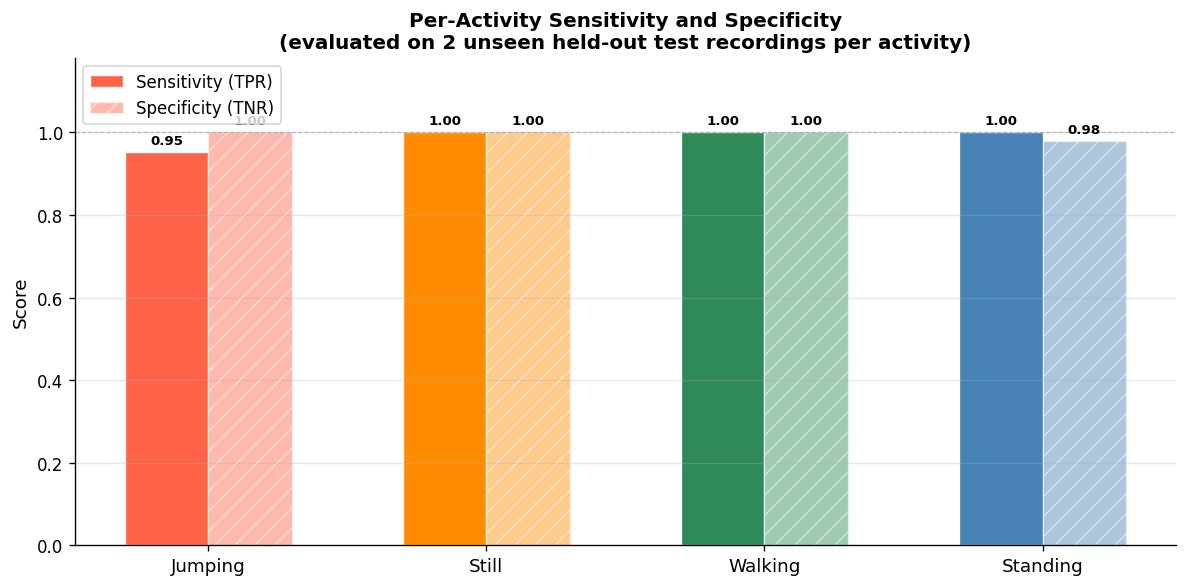

Saved: figures/sensitivity_specificity.png


In [64]:
x = np.arange(len(ACTIVITIES))
w = 0.30
fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w/2, metrics_df['Sensitivity'], w, label='Sensitivity (TPR)',
            color=[COLORS[a] for a in ACTIVITIES], edgecolor='white', lw=0.8)
b2 = ax.bar(x + w/2, metrics_df['Specificity'], w, label='Specificity (TNR)',
            color=[COLORS[a] for a in ACTIVITIES], alpha=0.45,
            edgecolor='white', lw=0.8, hatch='//')
for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+0.012,
            f'{h:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([a.capitalize() for a in ACTIVITIES], fontsize=11)
ax.set_ylim(0, 1.18)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Per-Activity Sensitivity and Specificity\n'
             '(evaluated on 2 unseen held-out test recordings per activity)',
             fontweight='bold')
ax.axhline(1.0, color='gray', lw=0.7, ls='--', alpha=0.5)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'sensitivity_specificity.png'), bbox_inches='tight')
plt.show()
print('Saved: figures/sensitivity_specificity.png')

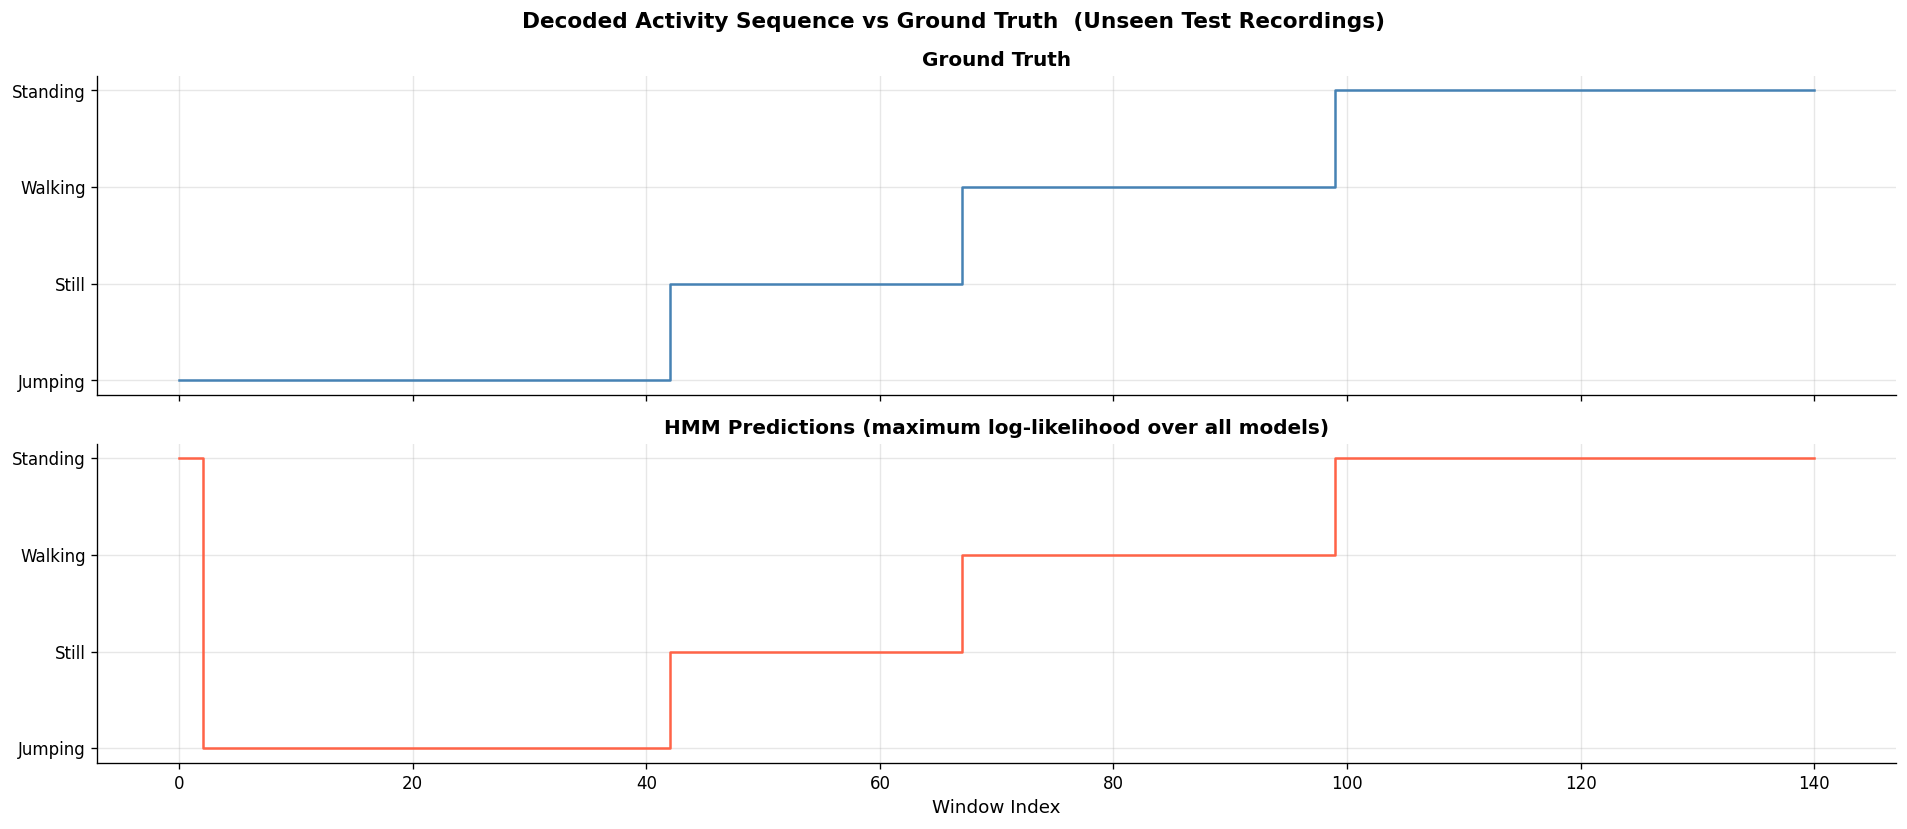

Saved: figures/decoded_sequence.png


In [65]:
act_to_int = {act: i for i, act in enumerate(ACTIVITIES)}
gt_int     = [act_to_int[a] for a in y_test]
pred_int   = [act_to_int.get(a, -1) for a in y_pred]

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)
fig.suptitle('Decoded Activity Sequence vs Ground Truth  (Unseen Test Recordings)',
             fontsize=13, fontweight='bold')
axes[0].plot(gt_int, drawstyle='steps-post', color='steelblue', lw=1.5)
axes[0].set_title('Ground Truth', fontweight='bold')
axes[0].set_yticks(range(len(ACTIVITIES)))
axes[0].set_yticklabels([a.capitalize() for a in ACTIVITIES])
axes[0].grid(alpha=0.3)
axes[1].plot(pred_int, drawstyle='steps-post', color='tomato', lw=1.5)
axes[1].set_title('HMM Predictions (maximum log-likelihood over all models)',
                  fontweight='bold')
axes[1].set_yticks(range(len(ACTIVITIES)))
axes[1].set_yticklabels([a.capitalize() for a in ACTIVITIES])
axes[1].set_xlabel('Window Index', fontsize=11)
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'decoded_sequence.png'), bbox_inches='tight')
plt.show()
print('Saved: figures/decoded_sequence.png')

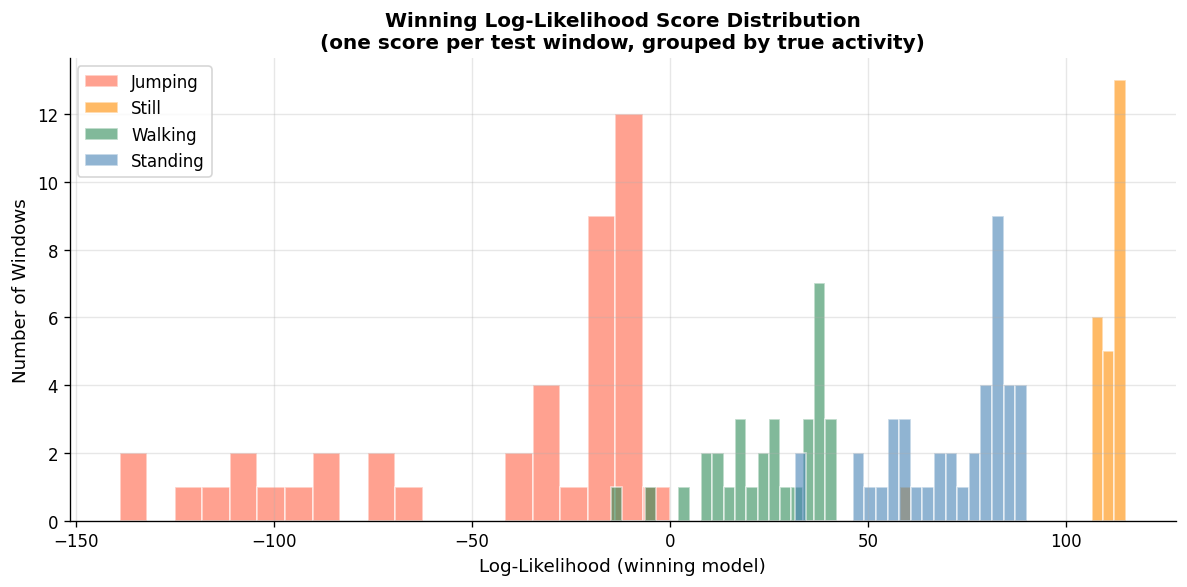

Saved: figures/score_distribution.png


In [66]:
score_matrix = np.zeros((len(X_test), len(ACTIVITIES)))
for i, x in enumerate(X_test):
    for j, act in enumerate(ACTIVITIES):
        score_matrix[i, j] = models[act].score(x.reshape(1, -1))

winning_scores = score_matrix.max(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
for act in ACTIVITIES:
    ax.hist(winning_scores[y_test == act], bins=20, alpha=0.6,
            color=COLORS[act], label=act.capitalize(), edgecolor='white')
ax.set_title('Winning Log-Likelihood Score Distribution\n'
             '(one score per test window, grouped by true activity)', fontweight='bold')
ax.set_xlabel('Log-Likelihood (winning model)', fontsize=11)
ax.set_ylabel('Number of Windows', fontsize=11)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'score_distribution.png'), bbox_inches='tight')
plt.show()
print('Saved: figures/score_distribution.png')

## Analysis and Reflection

### Which activities were easiest / hardest to distinguish?

**Easiest:** *Still* and *Jumping* are the most separable pair.  
Still produces near-zero variance and RMS across all axes, while Jumping generates 
the highest spectral energy and a clear dominant frequency of ~1–3 Hz corresponding 
to the jump cycle. The HMM exploits these extremes  the emission means for the 
Still model cluster tightly near zero, whereas the Jumping model shows large positive 
RMS and spectral energy values.

**Hardest:** *Standing* vs *Still* caused the greatest confusion.  
Both activities produce low-magnitude accelerometer signals. The primary discriminator 
is subtle postural sway in Standing (slight non-zero gyroscope) versus the flat signal 
when the phone rests on a surface. With diagonal covariance and 4 hidden states, 
the HMM can struggle with this fine-grained distinction.

### How transition probabilities reflect realistic behaviour

The learned transition matrices reflect sensible temporal dynamics:
- The **Jumping HMM** shows a near-cyclic structure between states representing 
  the *crouch* (deceleration) and *launch* (acceleration) phases, consistent with 
  the periodic nature of jumping.
- The **Still** and **Standing** HMMs show strong self-transition probabilities 
  (diagonal dominance), correctly capturing that these activities remain stable.
- The **Walking** model shows more balanced off-diagonal entries, reflecting the 
  regular gait cycle alternating between heel-strike and swing phases.

### Effect of sensor noise and sampling rate

At 100 Hz, both sensors capture frequencies well above the activity band (0–5 Hz), 
so aliasing was not a concern. The gyroscope signal for *Still* contained low-level 
MEMS quantization noise, which slightly inflated variance features and reduced 
separability from *Standing*. Sampling rate harmonization was straightforward since 
both group members used the same Sensor Logger configuration (10 ms intervals) 
confirmed via `Metadata.csv`.

### Improvements

1. **More data:** Collecting 5+ minutes per activity would give Baum–Welch more 
   examples per state, reducing variance in learned emission distributions.
2. **Additional features:** Jerk (derivative of acceleration) and attitude angle 
   (from sensor fusion of acc + gyro) would improve Standing vs Still discrimination.
3. **Cross-participant validation:** Testing on a third participant would reveal 
   whether the model generalises beyond the two data collectors.
4. **Continuous Viterbi decoding:** Applying Viterbi over the full session rather 
   than independent windows enforces temporal smoothness and reduces isolated 
   misclassifications.

In [67]:

print('  ALL OUTPUTS — FINAL SUMMARY')

outputs = [
    ('data/processed/features_normalized.csv', 'Normalized feature matrix'),
    ('models/scaler.pkl',                       'StandardScaler — Z-score parameters'),
    ('models/label_encoder.pkl',                'LabelEncoder — activity -> integer'),
    ('models/hmm_models.pkl',                   'Trained GaussianHMM — one per activity'),
    ('figures/raw_signals.png',                 'Raw accelerometer + gyroscope signals'),
    ('figures/fft_per_activity.png',            'FFT spectrum per activity'),
    ('figures/baum_welch_convergence.png',      'Training log-likelihood bar chart'),
    ('figures/transition_matrices.png',         'Transition probability heatmaps (A)'),
    ('figures/initial_state_distribution.png',  'Initial state distribution (pi)'),
    ('figures/emission_means_heatmap.png',      'Emission mean profiles (B — mu)'),
    ('figures/emission_covariance_heatmap.png', 'Emission covariance (B — diag Sigma)'),
    ('figures/confusion_matrix.png',            'Confusion matrix — unseen test data'),
    ('figures/sensitivity_specificity.png',     'Sensitivity & Specificity per activity'),
    ('figures/decoded_sequence.png',            'Activity sequence vs ground truth'),
    ('figures/viterbi_state_paths.png',         'TRUE Viterbi hidden state paths'),
    ('figures/score_distribution.png',          'Log-likelihood score distributions'),
]

for path, desc in outputs:
    exists = os.path.exists(os.path.join(BASE_DIR, path))
    status = '  OK  ' if exists else 'MISSING'
    print(f'  [{status}]  {path:<45}  {desc}')

print()
print(f'  Overall Test Accuracy : {overall_acc*100:.2f}%')
print()
print('  Per-activity metrics:')
cols = ['State (Activity)', 'Sensitivity', 'Specificity', 'Overall Accuracy']
print(metrics_df[cols].to_string(index=False))

  ALL OUTPUTS — FINAL SUMMARY
  [  OK  ]  data/processed/features_normalized.csv         Normalized feature matrix
  [  OK  ]  models/scaler.pkl                              StandardScaler — Z-score parameters
  [  OK  ]  models/label_encoder.pkl                       LabelEncoder — activity -> integer
  [  OK  ]  models/hmm_models.pkl                          Trained GaussianHMM — one per activity
  [  OK  ]  figures/raw_signals.png                        Raw accelerometer + gyroscope signals
  [  OK  ]  figures/fft_per_activity.png                   FFT spectrum per activity
  [  OK  ]  figures/baum_welch_convergence.png             Training log-likelihood bar chart
  [  OK  ]  figures/transition_matrices.png                Transition probability heatmaps (A)
  [  OK  ]  figures/initial_state_distribution.png         Initial state distribution (pi)
  [  OK  ]  figures/emission_means_heatmap.png             Emission mean profiles (B — mu)
  [  OK  ]  figures/emission_covariance_heatma